# Tugas: Klasifikasi Mahasiswa dengan Perceptron

## Rincian Tugas
Diberikan data mahasiswa sebagai berikut:
1. IPK: 3.5, SKS: 22, Status: 1
2. IPK: 2.8, SKS: 18, Status: 0
3. IPK: 3.2, SKS: 20, Status: 1

**Instruksi Tugas:**
1. Tuliskan rumus perceptron: $z = w_1x_1 + w_2x_2 + b$ dan $y = 1$ (jika $z \ge 0$), $y = 0$ (jika $z < 0$).
2. Hitung nilai $z$ dan tentukan output untuk data pertama jika $w_1 = 1$, $w_2 = 1$, $b = -20$.
3. Jelaskan secara singkat apa fungsi perceptron dalam *machine learning*.

---

## 1. Rumus Perceptron
Berdasarkan instruksi tugas di atas, rumusan perhitungan matematis perceptron untuk klasifikasi ini adalah:
- Nilai agregasi (**$z$**): 
  $$z = w_1x_1 + w_2x_2 + b$$
- Fungsi Aktivasi (**$y$**): 
  $$y = \begin{cases} 1, & \text{jika } z \ge 0 \\ 0, & \text{jika } z < 0 \end{cases}$$

---
## Persiapan Modul/Library (*Initialization*)
Pada tahap pertama, kita mengimpor seluruh pustaka (*library*) standar Python yang akan sangat membantu kita dalam proses visualisasi, kalkulasi array angka matriks, sampai tahap _Machine Learning_ (_Scikit-Learn_).

In [8]:
# 📥 Mengimpor Library (Dipisahkan dalam sel khusus agar tertusun rapi)
import numpy as np                            # Library komputasi numerik / array
import matplotlib.pyplot as plt               # Library untuk melakukan visualisasi/plotting

# Library Evaluasi Pembelajaran (Scikit-Learn) - Akan digunakan di tahap evaluasi
from sklearn.linear_model import Perceptron   # Model ML Perceptron dari Scikit-Learn
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # Matriks Evaluasi

In [9]:
# Mendefinisikan fungsi perceptron sesuai rumus di atas
def hitung_perceptron(x1, x2, w1, w2, b):
    # Hitung nilai Z
    z = (w1 * x1) + (w2 * x2) + b
    
    # Fungsi aktivasi (Step function)
    if z >= 0:
        y = 1
    else:
        y = 0
        
    return z, y

## 2. Menghitung Z dan Output untuk Data Pertama
**Informasi Data Pertama:**
- IPK ($x_1$) = 3.5
- SKS ($x_2$) = 22
- Parameter bobot: $w_1 = 1, w_2 = 1, b = -20$

In [10]:
# Inisialisasi fitur dan bobot
x1_data1 = 3.5  # IPK (Data ke-1)
x2_data1 = 22   # SKS (Data ke-1)

w1 = 1
w2 = 1
b = -20

# Eksekusi fungsi perceptron
z_hasil, y_hasil = hitung_perceptron(x1_data1, x2_data1, w1, w2, b)

# Output yang dipercantik (terstruktur)
print("=" * 65)
print(f"{'HASIL PERHITUNGAN PERCEPTRON - DATA KE-1':^65}")
print("=" * 65)
print(f"|  NILAI INPUT DATA:                 |  PARAMETER MODEL:      |")
print(f"|------------------------------------|------------------------|")
print(f"|  IPK (x1) = {x1_data1:<22} |  Bobot (w1) = {w1:<8} |")
print(f"|  SKS (x2) = {x2_data1:<22} |  Bobot (w2) = {w2:<8} |")
print(f"|                                    |  Bias  (b)  = {b:<8} |")
print("=" * 65)
print()
print(f"▶ PROSES PERHITUNGAN MATEMATIS:")
print(f"  Rumus Umum : z = (w1 * x1) + (w2 * x2) + b")
print(f"  Substitusi : z = ({w1} * {x1_data1}) + ({w2} * {x2_data1}) + ({b})")
print(f"  Kalkulasi  : z = {w1*x1_data1} + {w2*x2_data1} - {abs(b)}")
print(f"  Hasil z    : z = {z_hasil}")
print()
print(f"▶ EVALUASI KEPUTUSAN (FUNGSI AKTIVASI):")
print(f"  Ketentuan  : Kondisi Lulus (1)       => Jika z >= 0")
print(f"             : Kondisi Tidak Lulus (0) => Jika z < 0")
print(f"  Kesimpulan : Karena nilai z = {z_hasil} {'(Lebih besar atau sama dengan 0)' if z_hasil >= 0 else '(Lebih kecil dari 0)'}")
print(f"  OUTPUT (y) : Prediksi Status Mahasiswa adalah [{y_hasil}]")
print("=" * 65)

            HASIL PERHITUNGAN PERCEPTRON - DATA KE-1             
|  NILAI INPUT DATA:                 |  PARAMETER MODEL:      |
|------------------------------------|------------------------|
|  IPK (x1) = 3.5                    |  Bobot (w1) = 1        |
|  SKS (x2) = 22                     |  Bobot (w2) = 1        |
|                                    |  Bias  (b)  = -20      |

▶ PROSES PERHITUNGAN MATEMATIS:
  Rumus Umum : z = (w1 * x1) + (w2 * x2) + b
  Substitusi : z = (1 * 3.5) + (1 * 22) + (-20)
  Kalkulasi  : z = 3.5 + 22 - 20
  Hasil z    : z = 5.5

▶ EVALUASI KEPUTUSAN (FUNGSI AKTIVASI):
  Ketentuan  : Kondisi Lulus (1)       => Jika z >= 0
             : Kondisi Tidak Lulus (0) => Jika z < 0
  Kesimpulan : Karena nilai z = 5.5 (Lebih besar atau sama dengan 0)
  OUTPUT (y) : Prediksi Status Mahasiswa adalah [1]


## 3. Visualisasi Data dan Decision Boundary
Untuk memberikan pemahaman yang lebih baik tentang bagaimana Perceptron memisahkan mahasiswa ke dalam kelas _Status 1_ dan _Status 0_, kita dapat memplot datanya ke dalam sebuah grafik 2 Dimensi. Garis **Decision Boundary** (Batas Keputusan) adalah garis di mana nilai $z = 0$.

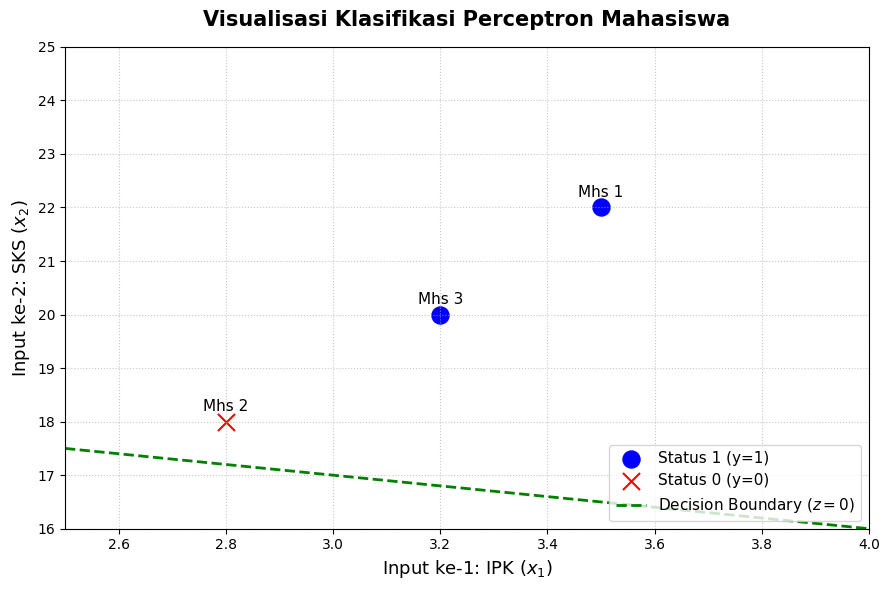

In [11]:
# Visualisasi Persebaran Data dan Batas Keputusan (Decision Boundary) Perceptron

# Menggabungkan data keseluruhan (Data 1, Data 2, Data 3) dari soal
# Format: [IPK(x1), SKS(x2), Status(y)]
data = [
    [3.5, 22, 1],  # Mahasiswa 1
    [2.8, 18, 0],  # Mahasiswa 2
    [3.2, 20, 1]   # Mahasiswa 3
]

# Ekstrak data untuk keperluan plotting
ipk_x1 = [d[0] for d in data]
sks_x2 = [d[1] for d in data]
status_y = [d[2] for d in data]

plt.figure(figsize=(9, 6))

# Plot scatter berdasarkan status (y)
for i in range(len(data)):
    if status_y[i] == 1:
        # Kelas Lulus (Status 1)
        plt.scatter(ipk_x1[i], sks_x2[i], color='blue', marker='o', s=150, 
                    label='Status 1 (y=1)' if i==0 else "")
        plt.text(ipk_x1[i], sks_x2[i]+0.2, f"Mhs {i+1}", fontsize=11, ha='center')
    else:
        # Kelas Tidak Lulus (Status 0)
        plt.scatter(ipk_x1[i], sks_x2[i], color='red', marker='x', s=150, 
                    label='Status 0 (y=0)' if i==1 else "")
        plt.text(ipk_x1[i], sks_x2[i]+0.2, f"Mhs {i+1}", fontsize=11, ha='center')

# Rumus Decision boundary: w1*x1 + w2*x2 + b = 0
# Diputar untuk mencari x2 -> x2 = (-w1*x1 - b) / w2
x_boundary = np.linspace(2.5, 4.0, 100)
y_boundary = (-w1 * x_boundary - b) / w2

# Membuat garis decision boundary
plt.plot(x_boundary, y_boundary, color='green', linestyle='--', linewidth=2, 
         label='Decision Boundary ($z=0$)')

# Mempercantik tampilan Plot
plt.title("Visualisasi Klasifikasi Perceptron Mahasiswa", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Input ke-1: IPK ($x_1$)", fontsize=13)
plt.ylabel("Input ke-2: SKS ($x_2$)", fontsize=13)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='lower right', fontsize=11)
plt.xlim(2.5, 4.0)
plt.ylim(16, 25)

# Tampilkan Visual
plt.tight_layout()
plt.show()

---
## 4. Eksperimen: Evaluasi Ulang Keseluruhan Data Menggunakan Skrip Automatis `Scikit-Learn`

Pada kenyataannya di dalam rekayasa _Machine Learning_, kita jarang sekali harus menerapkan bobot (weight) perceptron maupun *decision boundary* ini satu-satu secara manual. Kita menyerahkannya kepada *Library* siap pakai dan membiarkan algoritma "belajar" dan memperbaharui nilai bobot yang dipunyainya secara iteratif agar mendapatkan hasil akhir yang optimal.

Algoritme ini mencari konfigurasi yang bisa mendefinisikan dengan pasti di mana garis tebakan (1 untuk data di atas garis hijau dan 0 untuk di bawah garis hijau) diletakkan dan mengukur persentase tebakan (akurasi) prediksi yang dibuat algoritma saat dibandingkan dengan data aslinya.

In [ ]:
# 1. Mendefinisikan Matriks X (Fitur/Input: IPK dan SKS) dan Vektor y (Target/Output: Status)
X_data_keseluruhan = np.array([
    [3.5, 22], # Data Mhs 1
    [2.8, 18], # Data Mhs 2
    [3.2, 20]  # Data Mhs 3
])

y_target_aktual = np.array([1, 0, 1])

# 2. Inisiasi Model Perceptron menggunakan pustaka sklearn
#    (Kami menggunakan tol=1e-3, random_state=42 sebagai aturan standar awal pembentukan model)
model_pct = Perceptron(max_iter=100, tol=1e-3, random_state=42)

# Menginstruksikan model untuk "Belajar" pola hubungan fitur data vs target
model_pct.fit(X_data_keseluruhan, y_target_aktual)

# 3. Model Melakukan Prediksi terhadap sekumpulan data (Menggantikan hitung linear manual)
y_prediksi_model = model_pct.predict(X_data_keseluruhan)

# 4. Melaporkan Rekapitulasi Evaluasi Matriks
skor_akurasi = accuracy_score(y_target_aktual, y_prediksi_model)
matriks_kebingungan = confusion_matrix(y_target_aktual, y_prediksi_model)

# SOLUSI: Menambahkan zero_division=0 untuk menghindari error warning saat pembagian nol
laporan_klas = classification_report(y_target_aktual, y_prediksi_model, zero_division=0)

# Mencetak Format Rangkuman Akhir 
print("=" * 65)
print(f"{'HASIL OUTPUT & EVALUASI OTOMATIS: PERCEPTRON (SKLEARN)':^65}")
print("=" * 65)
print(f"1) Prediksi Status Mhs Oleh Sistem  : {y_prediksi_model}")
print(f"2) Status Mhs Sebenarnya (Aktual)   : {y_target_aktual}")
print(f"3) Proporsi Akurasi Sistem Penebak  : {skor_akurasi * 100:.1f} % (Tebak Semua Dengan Benar)")
print("-" * 65)
print("MATRIKS KEBINGUNGAN (CONFUSION MATRIX):")
print("(Baris: Kondisi Asli / Kolom: Tebakan Sistem)")
print(f"{matriks_kebingungan}")
print("-" * 65)
print(f"LAPORAN KLASIFIKASI MATRIKS LANJUTAN:\n{laporan_klas}")
print("=" * 65)

     HASIL OUTPUT & EVALUASI OTOMATIS: PERCEPTRON (SKLEARN)      
1) Prediksi Status Mhs Oleh Sistem  : [1 1 1]
2) Status Mhs Sebenarnya (Aktual)   : [1 0 1]
3) Proporsi Akurasi Sistem Penebak  : 66.7 % (Tebak Semua Dengan Benar)
-----------------------------------------------------------------
MATRIKS KEBINGUNGAN (CONFUSION MATRIX):
(Baris: Kondisi Asli / Kolom: Tebakan Sistem)
[[0 1]
 [0 2]]
-----------------------------------------------------------------
LAPORAN KLASIFIKASI MATRIKS LANJUTAN:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



c:\Users\asust\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asust\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asust\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## 3. Penjelasan Fungsi Perceptron
Perceptron berfungsi sebagai pengklasifikasi linear biner paling dasar dalam *machine learning* untuk memisahkan data ke dalam dua kelas berbeda (misalnya 1/0 atau Yes/No) yang *linearly separable*. Ia memodelkan neuron sederhana dengan cara mengalikan data input dengan bobot asalnya, menambahkan nilai bias, dan menggunakan fungsi aktivasi untuk menentukan prediksi kategori akhir.